<h1>Insurance Policy Data Analysis Project - 2026</h1>

In [23]:
## Created on 16 Jan 2026, 03:00 PM
# This project is made using python version 3.11.9
# Project is made by Darshil M. Vaghela

### Dataset

<div style="width: 70%; text-align: justify;">
<strong>Source:</strong><br>
<a href="https://huggingface.co/datasets/IINOVAII/Insurance_Dataset" target="_blank">
https://huggingface.co/datasets/IINOVAII/Insurance_Dataset
</a>
</div>

# SmartPolicy

## Abstract

<div style="width: 70%; text-align: justify;">
The accurate prediction of insurance charges plays a crucial role in the insurance industry, enabling insurers and policyholders to make informed decisions and effectively manage risk. This project employs data science techniques to predict insurance charges based on a diverse range of factors, providing valuable insights into the underlying drivers of pricing. Using a comprehensive dataset that incorporates various attributes of insured individuals, this study leverages data science and statistical analysis to uncover patterns and relationships between these attributes and insurance charges. By employing predictive modeling, this project aims to develop a robust framework for estimating insurance costs, thereby enhancing decision-making processes. While the specific algorithms and techniques utilized in this project are not discussed in this abstract, the focus remains on the predictive capability of the model and the potential benefits it offers. Accurate prediction of insurance charges allows policyholders to evaluate and select insurance plans that align with their specific needs and budgets. Insurers, on the other hand, can leverage these predictions to improve risk assessment, pricing strategies, and overall profitability. The project's findings shed light on the factors that significantly impact insurance charges, highlighting the relative importance of variables such as age, gender, smoking habits, pre-existing medical conditions, and geographic location. This understanding aids insurers in developing customized insurance products, tailored to the needs of different customer segments, while ensuring fair pricing practices.
</div>

Import Libraries

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

Import Dataset

In [2]:
data = pd.read_csv(r"Dataset.csv")

In [4]:
data.head(3)

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,23-12-2023,Poor,No,Weekly,House,2869
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,12-06-2023,Average,Yes,Monthly,House,1483
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,30-09-2023,Good,Yes,Weekly,House,567


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1048575 non-null  int64  
 1   Age                   1032254 non-null  float64
 2   Gender                1048575 non-null  object 
 3   Annual Income         1009366 non-null  float64
 4   Marital Status        1032269 non-null  object 
 5   Number of Dependents  952871 non-null   float64
 6   Education Level       1048575 non-null  object 
 7   Occupation            735638 non-null   object 
 8   Health Score          983942 non-null   float64
 9   Location              1048575 non-null  object 
 10  Policy Type           1048575 non-null  object 
 11  Previous Claims       730583 non-null   float64
 12  Vehicle Age           1048570 non-null  float64
 13  Credit Score          928164 non-null   float64
 14  Insurance Duration    1048574 non-

In [4]:
data.describe()

,id,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount
count,1.048575e+06,1.032254e+06,1.009366e+06,952871.000000,983942.000000,730583.000000,1.048570e+06,928164.000000,1.048574e+06,1.048575e+06
mean,5.242870e+05,4.114057e+01,3.276203e+04,2.009702,25.610221,1.002773,9.570021e+00,592.940001,5.019679e+00,1.102495e+03
std,3.026977e+05,1.353652e+01,3.220290e+04,1.417424,12.203206,0.982726,5.774606e+00,149.972058,2.593570e+00,8.654324e+02
min,0.000000e+00,1.800000e+01,1.000000e+00,0.000000,2.012237,0.000000,0.000000e+00,300.000000,1.000000e+00,2.000000e+01
25%,2.621435e+05,3.000000e+01,7.991000e+03,1.000000,15.919120,0.000000,5.000000e+00,468.000000,3.000000e+00,5.140000e+02
50%,5.242870e+05,4.100000e+01,2.393400e+04,2.000000,24.573981,1.000000,1.000000e+01,595.000000,5.000000e+00,8.720000e+02
75%,7.864305e+05,5.300000e+01,4.463600e+04,3.000000,34.520860,2.000000,1.500000e+01,721.000000,7.000000e+00,1.509000e+03
max,1.048574e+06,6.400000e+01,1.499970e+05,4.000000,58.975914,9.000000,1.900000e+01,849.000000,9.000000e+00,4.999000e+03


In [5]:
data.isnull().sum()

id                           0
Age                      16321
Gender                       0
Annual Income            39209
Marital Status           16306
Number of Dependents     95704
Education Level              0
Occupation              312937
Health Score             64633
Location                     0
Policy Type                  0
Previous Claims         317992
Vehicle Age                  5
Credit Score            120411
Insurance Duration           1
Policy Start Date            0
Customer Feedback        67873
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

<h2>Data Cleaning and Dealing with null values</h2>

## Feature Selection

### Columns to Remove
The following columns are not useful for the model and will be removed:

1. **ID**
2. **Marital Status**
3. **Education Level**
4. **Location**
5. **Vehicle Age**
6. **Customer Feedback**
7. **Property Type**

---

### Optional Column
This column may be removed depending on model performance:

- **Gender**

---

### Columns to Keep (Important Features)

The following features will be used for training the model:

- **Age**
- **Annual Income**
- **Number of Dependents**
- **Occupation**
- **Health Score**
- **Policy Type**
- **Previous Claims**
- **Credit Score**
- **Insurance Duration**
- **Smoking Status**
- **Exercise Frequency**

In [ ]:
# Columns to remove
columns_to_remove = [
    "id",
    "Marital Status",
    "Education Level",
    "Location",
    "Vehicle Age",
    "Customer Feedback",
    "Property Type"
]

data = data.drop(columns=columns_to_remove)

Decide Missing-Value Strategy

A. Columns with Very Low Missing Values

In [ ]:
data["Insurance Duration"].fillna(data["Insurance Duration"].median(), inplace=True)

B. Numerical Columns with Moderate Missing Values

Use Median

In [5]:
num_cols = ["Age", "Annual Income", "Health Score", "Credit Score"]

for col in num_cols:
    data[col].fillna(data[col].median(), inplace=True)

C. Columns with Extremely High Missing Values

In [6]:
data["Occupation"].fillna("Unknown", inplace=True)

1. Previous Claims → 0

In [7]:
data["Previous Claims"].fillna(0, inplace=True)

2. Number of Dependents → Median

In [8]:
data["Number of Dependents"].fillna(data["Number of Dependents"].median(), inplace=True)

D. Special Case: Policy Start Date
<br>Convert it into useful features:
<br>- Policy start year
<br>- Policy age (years)

In [ ]:
data["Policy Start Date"] = pd.to_datetime(data["Policy Start Date"])

# Create Policy Start Year
data["Policy Start Year"] = data["Policy Start Date"].dt.year

# Create Policy Age (in years)
current_year = pd.Timestamp.now().year
data["Policy Age (Years)"] = current_year - data["Policy Start Year"]

data = data.drop(columns=["Policy Start Date"])

C:\Users\Darshil Vaghela\AppData\Local\Temp\ipykernel_22824\2047564037.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data["Policy Start Date"] = pd.to_datetime(data["Policy Start Date"])


### Cleaned Dataset

In [10]:
# Save cleaned dataset
data.to_csv("clean_dataset.csv", index=False)

In [5]:
clean_dataset = pd.read_csv("clean_dataset.csv")

In [14]:
clean_dataset.head(5)

,Age,Gender,Annual Income,Number of Dependents,Occupation,Health Score,Policy Type,Previous Claims,Credit Score,Insurance Duration,Smoking Status,Exercise Frequency,Premium Amount,Policy Start Year,Policy Age (Years)
0,19.0,Female,10049.0,1.0,Self-Employed,22.598761,Premium,2.0,372.0,5.0,No,Weekly,2869,2023,3
1,39.0,Female,31678.0,3.0,Unknown,15.569731,Comprehensive,1.0,694.0,2.0,Yes,Monthly,1483,2023,3
2,23.0,Male,25602.0,3.0,Self-Employed,47.177549,Premium,1.0,595.0,3.0,Yes,Weekly,567,2023,3
3,21.0,Male,141855.0,2.0,Unknown,10.938144,Basic,1.0,367.0,1.0,Yes,Daily,765,2024,2
4,21.0,Male,39651.0,1.0,Self-Employed,20.376094,Premium,0.0,598.0,4.0,Yes,Weekly,2022,2021,5


In [15]:
clean_dataset.isnull().sum()

Age                     0
Gender                  0
Annual Income           0
Number of Dependents    0
Occupation              0
Health Score            0
Policy Type             0
Previous Claims         0
Credit Score            0
Insurance Duration      0
Smoking Status          0
Exercise Frequency      0
Premium Amount          0
Policy Start Year       0
Policy Age (Years)      0
dtype: int64

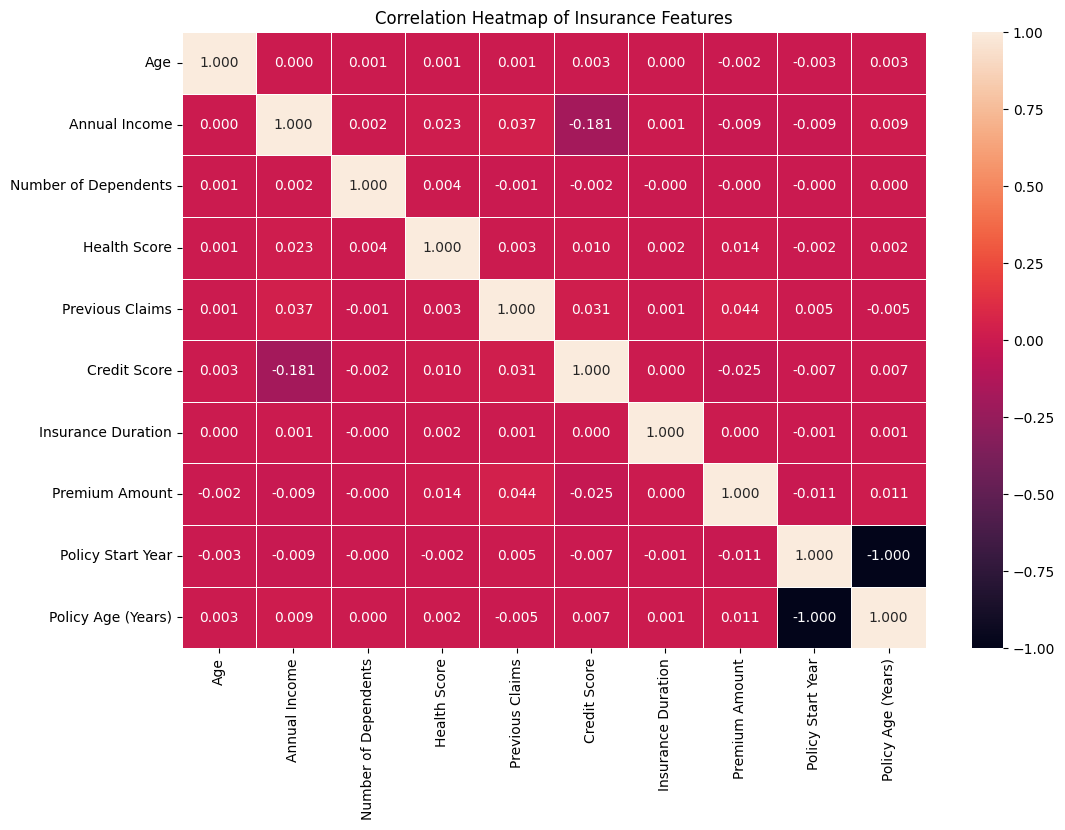

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Credit Score,Insurance Duration,Premium Amount,Policy Start Year,Policy Age (Years)
Age,1.000000,0.000591,0.001054,0.001217,0.000885,0.003393,0.000089,-0.002270,-0.003146,0.003146
Annual Income,0.000591,1.000000,0.003204,0.012074,0.000305,-0.133444,0.000513,-0.059511,-0.003725,0.003725
Number of Dependents,0.001054,0.003204,1.000000,0.004545,-0.000146,-0.001456,-0.000075,-0.000906,-0.000263,0.000263
Health Score,0.001217,0.012074,0.004545,1.000000,0.002771,0.007846,0.002626,0.015265,-0.001209,0.001209
Previous Claims,0.000885,0.000305,-0.000146,0.002771,1.000000,0.028339,0.001029,0.039368,0.004485,-0.004485
Credit Score,0.003393,-0.133444,-0.001456,0.007846,0.028339,1.000000,0.000669,-0.041761,-0.006684,0.006684
Insurance Duration,0.000089,0.000513,-0.000075,0.002626,0.001029,0.000669,1.000000,0.000076,-0.001194,0.001194
Premium Amount,-0.002270,-0.059511,-0.000906,0.015265,0.039368,-0.041761,0.000076,1.000000,-0.010575,0.010575
Policy Start Year,-0.003146,-0.003725,-0.000263,-0.001209,0.004485,-0.006684,-0.001194,-0.010575,1.000000,-1.000000
Policy Age (Years),0.003146,0.003725,0.000263,0.001209,-0.004485,0.006684,0.001194,0.010575,-1.000000,1.000000


In [ ]:
numeric_df = clean_dataset.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_df.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="rocket",
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".3f",
    linewidths=0.5,
    cbar=True
)

plt.title("Correlation Heatmap of Insurance Features")
plt.show()

df_encoded = pd.get_dummies(clean_dataset, drop_first=True)
corr = df_encoded.corr()

numeric_df.corr(method='spearman')

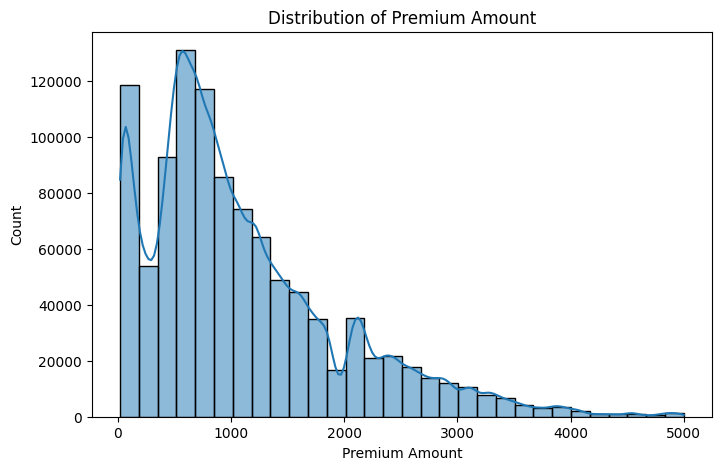

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.histplot(
    clean_dataset['Premium Amount'],
    bins=30,
    kde=True
)

plt.xlabel("Premium Amount")
plt.ylabel("Count")
plt.title("Distribution of Premium Amount")
plt.show()


C:\Users\Darshil Vaghela\AppData\Local\Temp\ipykernel_5412\763258572.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


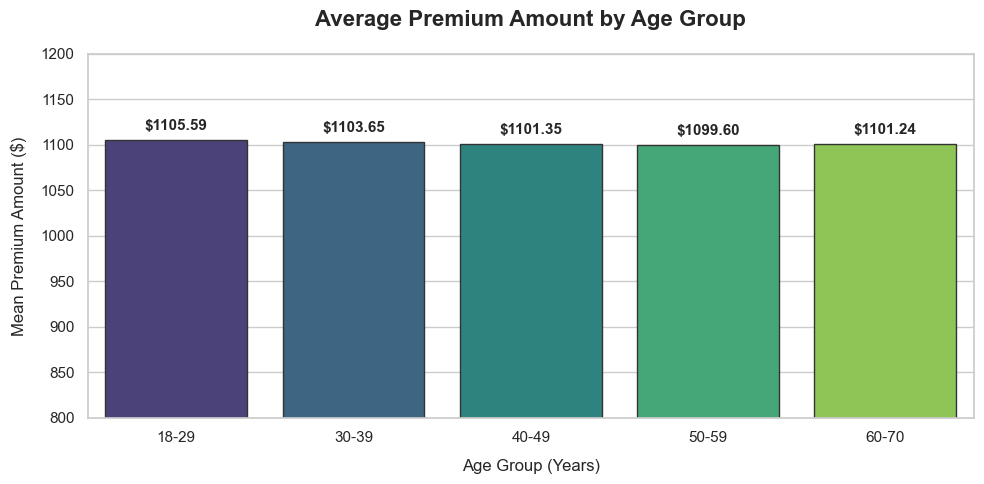

In [6]:
df = pd.read_csv('clean_dataset.csv')

bins = [18, 30, 40, 50, 60, 71]
labels = ['18-29', '30-39', '40-49', '50-59', '60-70']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x='Age Group', 
    y='Premium Amount', 
    data=df, 
    estimator='mean', 
    palette='viridis',
    edgecolor=".2",
    errorbar=None
)

plt.ylim(800, 1200)

plt.title('Average Premium Amount by Age Group', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Age Group (Years)', fontsize=12, labelpad=10)
plt.ylabel('Mean Premium Amount ($)', fontsize=12, labelpad=10)

for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Based on the statistical analysis of your data, here are the key insights regarding the relationship between Premium Amount and Age Group:

1. High Price Stability Across Ages
The most striking insight is that the premium amount is remarkably consistent across all age groups. In many insurance models, premiums rise significantly with age, but your dataset shows a "flat" pricing structure:

Maximum Mean: $1,105.59 (Age Group 18-29)

Minimum Mean: $1,099.60 (Age Group 50-59)

Total Variance: Only $5.99 across the entire lifespan (18 to 69 years).

2. Slight Inverse Relationship
Interestingly, the data shows a very subtle downward trend as customers get older, until they reach their 60s:

The youngest group (18-29) actually pays the highest average premium.

The cost decreases slightly for each subsequent decade until age 60.

Interpretation: This often occurs when younger drivers or policyholders are perceived as higher risk, or when "loyalty" or "experience" discounts are applied as age increases.

3. Consistency in "Middle-Age" (30–60)
The premiums for the 30s, 40s, and 50s brackets are nearly identical, with differences of only $1–$2. This suggests that for the vast majority of the adult working population, age is not a primary factor used to differentiate price in this specific insurance product.

4. Dominance of Non-Age Factors
Since the variation across age groups is less than 0.6%, it is highly likely that other variables in your dataset (such as Annual Income, Credit Score, or Policy Type) are the actual drivers of the premium amount.

Summary for Report:
"The data reveals an unusually stable pricing model where age does not significantly influence the cost of the premium. The maximum difference between the youngest and oldest cohorts is less than $6, suggesting that the insurance product is likely priced based on fixed policy tiers or other socio-economic factors rather than traditional age-based risk assessment."

C:\Users\Darshil Vaghela\AppData\Local\Temp\ipykernel_5412\814874844.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


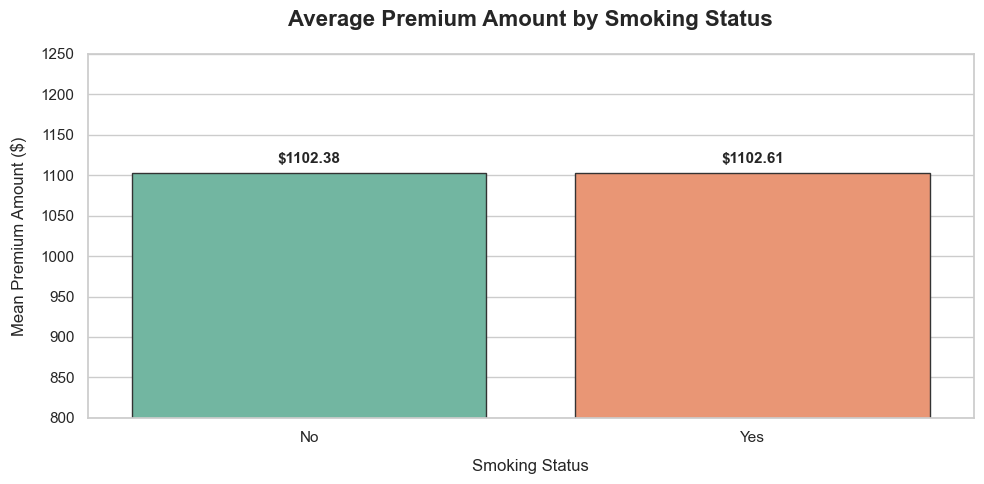

In [7]:
df = pd.read_csv('clean_dataset.csv')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x='Smoking Status', 
    y='Premium Amount', 
    data=df, 
    estimator='mean', 
    palette='Set2',
    edgecolor=".2",
    errorbar=None
)

plt.ylim(800, 1250)

plt.title('Average Premium Amount by Smoking Status', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Smoking Status', fontsize=12, labelpad=10)
plt.ylabel('Mean Premium Amount ($)', fontsize=12, labelpad=10)

for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Based on the statistical analysis of your dataset, here are the professional insights regarding the relationship between Premium Amount and Smoking Status:

1. Negligible Impact on Pricing
In traditional insurance models, smoking is a primary risk factor that significantly increases costs. However, in your dataset, the impact is statistically insignificant:

Average Premium (Smokers): $1,102.61

Average Premium (Non-Smokers): $1,102.38

The Difference: Only $0.23. This indicates that smoking status is not a main driver of the premium cost in this specific data.

2. Identical Median and Distribution
Both smokers and non-smokers have a median premium of $872.00.

The spread of the data (Standard Deviation) is also nearly identical (~$865).

Whether a customer smokes or not, they are just as likely to fall into the low-cost or high-cost bracket.

3. Broad "Flat-Rate" Behavior
The lack of a "Smoking Surcharge" suggests one of the following:

Broad Policy Pricing: The insurer may be using a simplified pricing model that prioritizes other factors (like fixed policy types) over individual health behaviors.

Dominance of Other Variables: Factors like Policy Type or Annual Income might be influencing the price more than health-related habits.

Summary for Report:
"Analysis reveals that lifestyle choices, specifically Smoking Status, do not currently correlate with Premium Amount variations within this portfolio. Both groups exhibit a mean premium of approximately $1,102, suggesting that lifestyle-based risk loading is either not applied or is heavily diluted by other pricing parameters."

In [23]:
clean_dataset["Smoking Status"].value_counts()

Smoking Status
Yes    525841
No     522734
Name: count, dtype: int64

C:\Users\Darshil Vaghela\AppData\Local\Temp\ipykernel_5412\3113203408.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


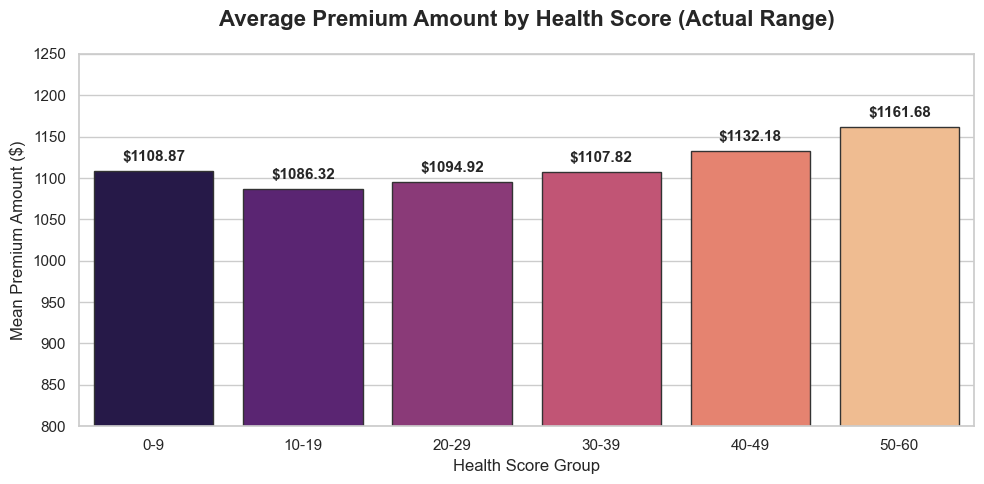

In [8]:
df = pd.read_csv('clean_dataset.csv')

bins = [0, 10, 20, 30, 40, 50, 61]
labels = ['0-9', '10-19', '20-29', '30-39', '40-49', '50-60']
df['Health Group'] = pd.cut(df['Health Score'], bins=bins, labels=labels, right=False)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x='Health Group', 
    y='Premium Amount', 
    data=df, 
    estimator='mean', 
    palette='magma', 
    edgecolor=".2",
    errorbar=None
)

plt.ylim(800, 1250)

plt.title('Average Premium Amount by Health Score (Actual Range)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Health Score Group', fontsize=12)
plt.ylabel('Mean Premium Amount ($)', fontsize=12)

for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Maximum Health Score: 58.98
<br>Scores $\ge$ 60: 0 records

### Models

<div style="width: 70%; text-align: justify;">

The following machine learning models were used for prediction:

- Linear Regression  
- Decision Tree  
- Random Forest  
- Gradient Boosting  
- SGD Regressor  

</div>

<h1>Simple model </h1>

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('clean_dataset.csv')

le = LabelEncoder()
categorical_cols = ['Gender', 'Occupation', 'Policy Type', 'Smoking Status', 'Exercise Frequency']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('Premium Amount', axis=1)
y = df['Premium Amount']

# Split into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def show_perf(name, y_true, y_pred):
    print(f"--- {name} ---")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"R2 Score: {r2_score(y_true, y_pred):.4f}\n")

In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
show_perf("Linear Regression", y_test, lr_pred)

train_score = lr_model.score(X_train_scaled, y_train)
test_score = lr_model.score(X_test_scaled, y_test)

print(f"Training Score: {train_score:.4f}")
print(f"Testing Score: {test_score:.4f}")

--- Linear Regression ---
MAE: 668.33
RMSE: 864.37
R2 Score: 0.0033

Training Score: 0.0033
Testing Score: 0.0033


In [11]:
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd_model.fit(X_train_scaled, y_train)

sgd_pred = sgd_model.predict(X_test_scaled)
show_perf("SGD Regressor", y_test, sgd_pred)

sgd_train_score = sgd_model.score(X_train_scaled, y_train)
sgd_test_score = sgd_model.score(X_test_scaled, y_test)

print(f"SGD Regressor Training Score: {sgd_train_score:.4f}")
print(f"SGD Regressor Testing Score: {sgd_test_score:.4f}")

--- SGD Regressor ---
MAE: 665.54
RMSE: 864.79
R2 Score: 0.0024

SGD Regressor Training Score: 0.0024
SGD Regressor Testing Score: 0.0024


In [12]:
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
show_perf("Decision Tree", y_test, dt_pred)

dt_train_score = dt_model.score(X_train, y_train)
dt_test_score = dt_model.score(X_test, y_test)

print(f"Decision Tree Training Score: {dt_train_score:.4f}")
print(f"Decision Tree Testing Score: {dt_test_score:.4f}")

--- Decision Tree ---
MAE: 640.69
RMSE: 847.49
R2 Score: 0.0419

Decision Tree Training Score: 0.0568
Decision Tree Testing Score: 0.0419


In [13]:
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
show_perf("Random Forest", y_test, rf_pred)

rf_train_score = rf_model.score(X_train, y_train)
rf_test_score = rf_model.score(X_test, y_test)

print(f"Random Forest Training Score: {rf_train_score:.4f}")
print(f"Random Forest Testing Score: {rf_test_score:.4f}")

--- Random Forest ---
MAE: 639.44
RMSE: 844.38
R2 Score: 0.0489

Random Forest Training Score: 0.0618
Random Forest Testing Score: 0.0489


In [14]:
gb_model = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
show_perf("Gradient Boosting", y_test, gb_pred)

gb_train_score = gb_model.score(X_train, y_train)
gb_test_score = gb_model.score(X_test, y_test)

print(f"Gradient Boosting Training Score: {gb_train_score:.4f}")
print(f"Gradient Boosting Testing Score: {gb_test_score:.4f}")

--- Gradient Boosting ---
MAE: 650.19
RMSE: 848.86
R2 Score: 0.0388

Gradient Boosting Training Score: 0.0414
Gradient Boosting Testing Score: 0.0388


<h1>Enginnered Model </h1>

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

df = pd.read_csv('clean_dataset.csv')

X = df.drop('Premium Amount', axis=1)
y = df['Premium Amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_cols = X_train.select_dtypes(include=[np.number]).columns
Q1, Q3 = X_train[numeric_cols].quantile(0.25), X_train[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
condition = ~((X_train[numeric_cols] < (Q1 - 1.5 * IQR)) | (X_train[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

X_train_clean = X_train[condition]
y_train_clean = y_train[condition]

categorical_cols = X_train_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    X_train_clean[col] = le.fit_transform(X_train_clean[col])
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    X_test[col] = X_test[col].apply(lambda x: le_dict.get(x, -1))

scaler = MinMaxScaler()
X_train_final = pd.DataFrame(scaler.fit_transform(X_train_clean), columns=X_train_clean.columns)
X_test_final = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

def print_metrics(name, y_true, y_pred):
    print(f"[{name} Results]")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"R2: {r2_score(y_true, y_pred):.4f}\n")

C:\Users\Darshil Vaghela\AppData\Local\Temp\ipykernel_5412\428456045.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_clean[col] = le.fit_transform(X_train_clean[col])
C:\Users\Darshil Vaghela\AppData\Local\Temp\ipykernel_5412\428456045.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_clean[col] = le.fit_transform(X_train_clean[col])
C:\Users\Darshil Vaghela\AppData\Local\Temp\ipykernel_5412\428456045.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice fr

In [17]:
model_lr = LinearRegression()
model_lr.fit(X_train_final, y_train_clean)

pred_lr = model_lr.predict(X_test_final)
print_metrics("Linear Regression", y_test, pred_lr)

lr_train_score = model_lr.score(X_train_final, y_train_clean)
lr_test_score = model_lr.score(X_test_final, y_test)

print(f"Linear Regression Training Score (R2): {lr_train_score:.4f}")
print(f"Linear Regression Testing Score (R2): {lr_test_score:.4f}")

[Linear Regression Results]
MAE: 666.59
RMSE: 864.82
R2: 0.0023

Linear Regression Training Score (R2): 0.0030
Linear Regression Testing Score (R2): 0.0023


In [18]:
model_dt = DecisionTreeRegressor(max_depth=10, random_state=42)
model_dt.fit(X_train_final, y_train_clean)

pred_dt = model_dt.predict(X_test_final)
print_metrics("Decision Tree", y_test, pred_dt)

dt_train_score = model_dt.score(X_train_final, y_train_clean)
dt_test_score = model_dt.score(X_test_final, y_test)

print(f"Decision Tree Training Score (R2): {dt_train_score:.4f}")
print(f"Decision Tree Testing Score (R2): {dt_test_score:.4f}")

[Decision Tree Results]
MAE: 642.15
RMSE: 851.49
R2: 0.0328

Decision Tree Training Score (R2): 0.0522
Decision Tree Testing Score (R2): 0.0328


In [19]:
model_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model_rf.fit(X_train_final, y_train_clean)

pred_rf = model_rf.predict(X_test_final)
print_metrics("Random Forest", y_test, pred_rf)

rf_train_score = model_rf.score(X_train_final, y_train_clean)
rf_test_score = model_rf.score(X_test_final, y_test)

print(f"Random Forest Training Score (R2): {rf_train_score:.4f}")
print(f"Random Forest Testing Score (R2): {rf_test_score:.4f}")

[Random Forest Results]
MAE: 640.12
RMSE: 844.80
R2: 0.0480

Random Forest Training Score (R2): 0.0592
Random Forest Testing Score (R2): 0.0480


In [20]:
model_gb = GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
model_gb.fit(X_train_final, y_train_clean)

pred_gb = model_gb.predict(X_test_final)
print_metrics("Gradient Boosting", y_test, pred_gb)

gb_train_score = model_gb.score(X_train_final, y_train_clean)
gb_test_score = model_gb.score(X_test_final, y_test)

print(f"Gradient Boosting Training Score (R2): {gb_train_score:.4f}")
print(f"Gradient Boosting Testing Score (R2): {gb_test_score:.4f}")

[Gradient Boosting Results]
MAE: 648.70
RMSE: 848.04
R2: 0.0406

Gradient Boosting Training Score (R2): 0.0452
Gradient Boosting Testing Score (R2): 0.0406


In [21]:
model_sgd = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
model_sgd.fit(X_train_final, y_train_clean)

pred_sgd = model_sgd.predict(X_test_final)
print_metrics("SGD Regressor", y_test, pred_sgd)

sgd_train_score = model_sgd.score(X_train_final, y_train_clean)
sgd_test_score = model_sgd.score(X_test_final, y_test)

print(f"SGD Regressor Training Score (R2): {sgd_train_score:.4f}")
print(f"SGD Regressor Testing Score (R2): {sgd_test_score:.4f}")

[SGD Regressor Results]
MAE: 662.76
RMSE: 865.23
R2: 0.0013

SGD Regressor Training Score (R2): 0.0024
SGD Regressor Testing Score (R2): 0.0013


Prediction

In [ ]:
import pandas as pd

raw_input = {
    'Age': 35,
    'Gender': 1,
    'Occupation': 2,
    'Policy Type': 1,
    'Smoking Status': 0,
    'Exercise Frequency': 2,
    'Annual Income': 50000,
    'Health Score': 80,
    'Credit Score': 700
}

input_df = pd.DataFrame([raw_input])

input_df = input_df.reindex(columns=X_train_final.columns, fill_value=0)

input_scaled = scaler.transform(input_df)

prediction = model_rf.predict(input_scaled)

print("--- Random Forest Prediction ---")
print(f"Predicted Premium Amount: ${prediction[0]:.2f}")

--- Random Forest Prediction ---
Predicted Premium Amount: $1261.47


C:\Users\Darshil Vaghela\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [22]:
import pickle

model_data = {
    "model": model_rf,
    "features": X_train_final.columns.tolist()
}

with open("rf_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Model saved successfully")

Model saved successfully


In [ ]:
# cd "d:\5. Insurance Prediction"
# streamlit run app.py